## Progetto 3

Implementare e confrontare due diversi algoritmi di classificazione, K-Nearest Neighbors (KNN) e Support Vector Machine (SVM), dopo aver ridotto la dimensionalità del dataset Wine utilizzando la PCA.

### 1 Data Exploration & Preprocessing

• Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale (i.e. df.describe(), df.dtypes)

• Standardization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

### 2 Data Dimensionality Reduction

• Applicare la PCA (Principal Component Analysis) sui dati standardizzati

• Ridurre la dimensionalità a 2 componenti principali (n components=2) per facilitare la visualizzazione

### 3 Addestramento & Valutazione

• Inizializzare due modelli:

  1. K-Nearest Neighbors (KNN) con n neighbors=5

  2. Support Vector Machine (SVM) con kernel=’linear’

• Addestrare entrambi i modelli utilizzando il dataset ridotto a 2 componenti

• Calcolare e stampare l’Accuracy Score di entrambi i modelli sull’intero set di dati ridotto

### 4 Analisi & Visualizzazione

• Generare un grafico con due subplot per confrontare i risultati visivi

• Plottare i data points colorati in base alla loro classe di appartenenza (target)

• Visualizzare i decision boundary dei modelli (KNN e SVM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

### 1. Data Exploration & Preprocessing

In [27]:
data = load_wine()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)

display(df.describe())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [28]:
display(df.dtypes)

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

In [22]:
# Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2. Data Dimensionality Reduction

In [23]:
# Principal Component Analysis
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### 3. Addestramento & Valutazione

In [24]:
# Modelli
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='linear')

# Training
knn.fit(X_pca, y)
svm.fit(X_pca, y)

# Predizioni
y_pred_knn = knn.predict(X_pca)
y_pred_svm = svm.predict(X_pca)

# Accuracy
print("Accuracy KNN:\t", accuracy_score(y, y_pred_knn))
print("Accuracy SVM:\t", accuracy_score(y, y_pred_svm))

Accuracy KNN:	 0.9662921348314607
Accuracy SVM:	 0.9719101123595506


### 4. Analisi & Visualizzazione

In [29]:
# Meshgrid
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

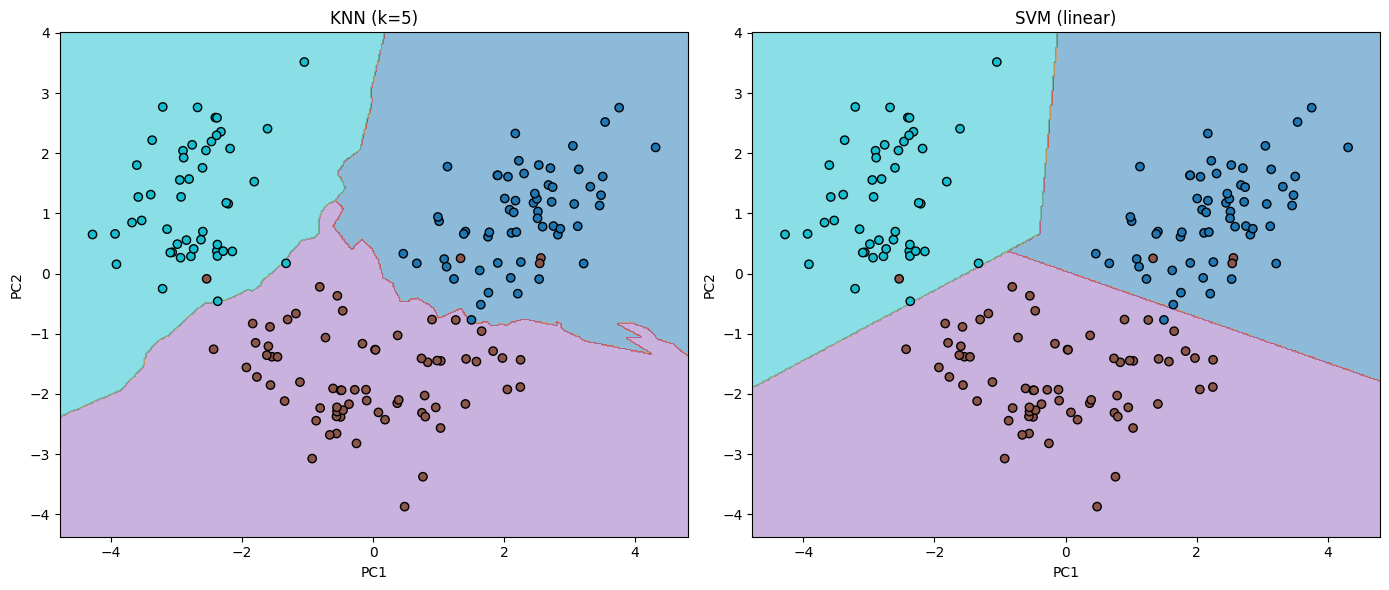

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [knn, svm]
titles = ["KNN (k=5)", "SVM (linear)"]

for i, model in enumerate(models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, cmap='tab10', alpha=0.5)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', edgecolor='k')

    axes[i].set_title(titles[i])
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")

plt.tight_layout()
plt.show()